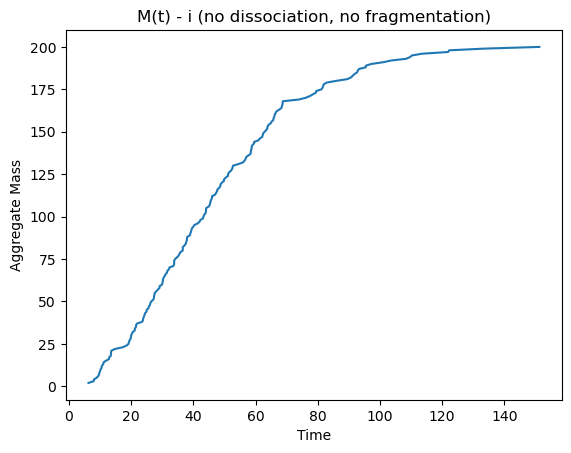

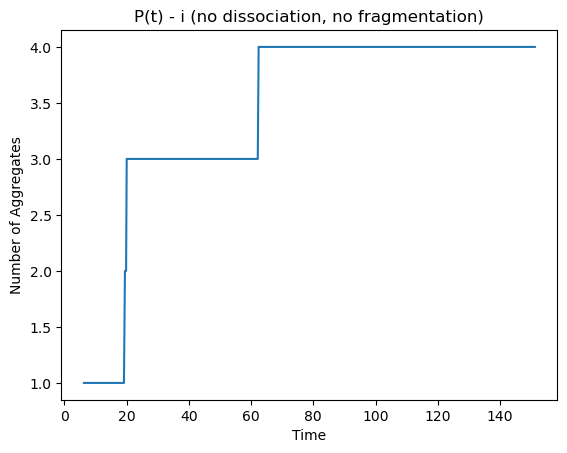

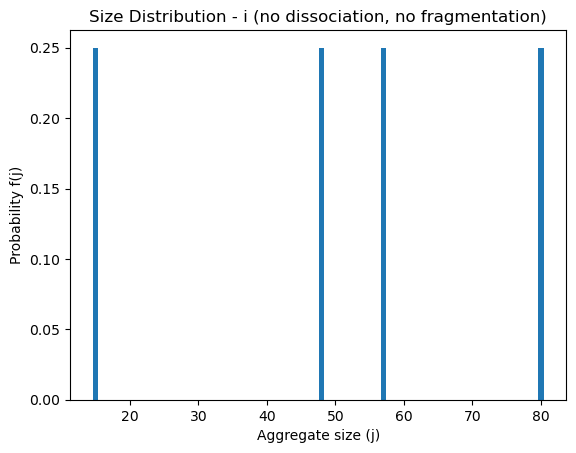

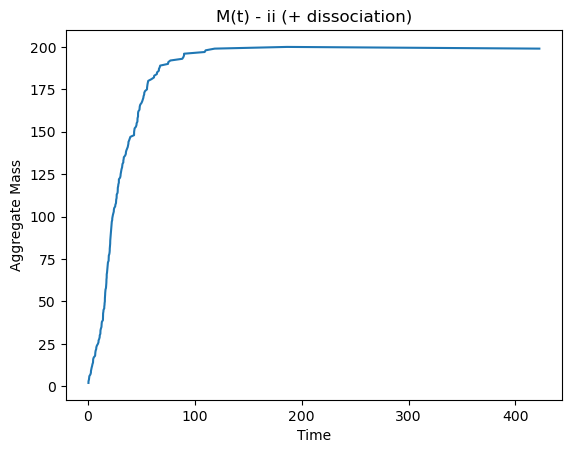

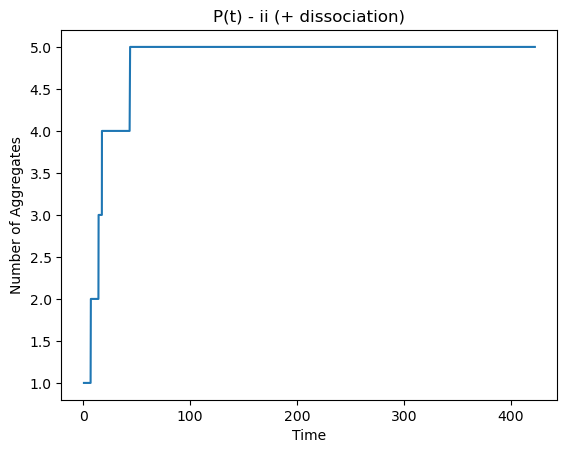

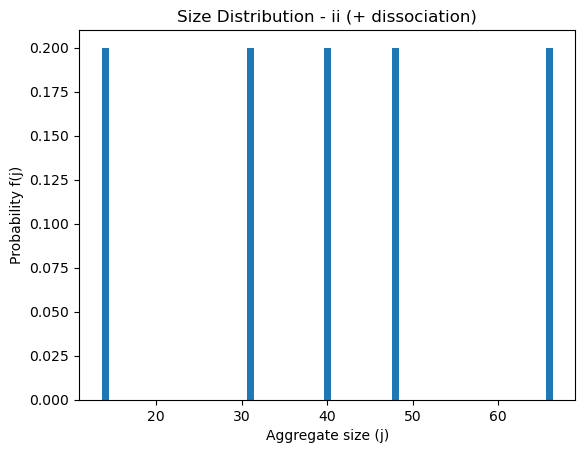

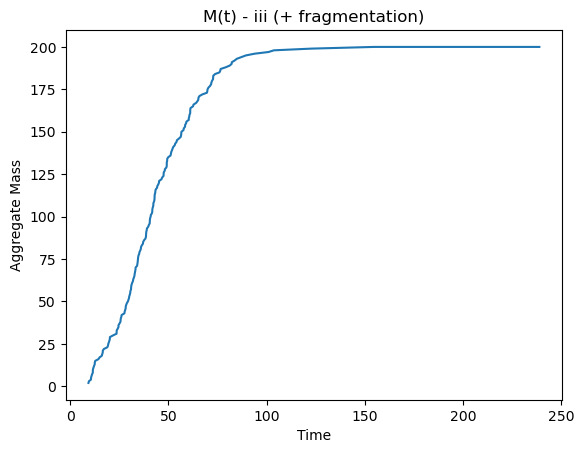

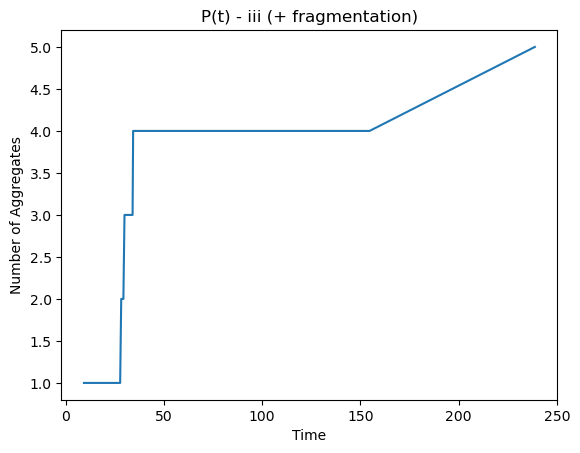

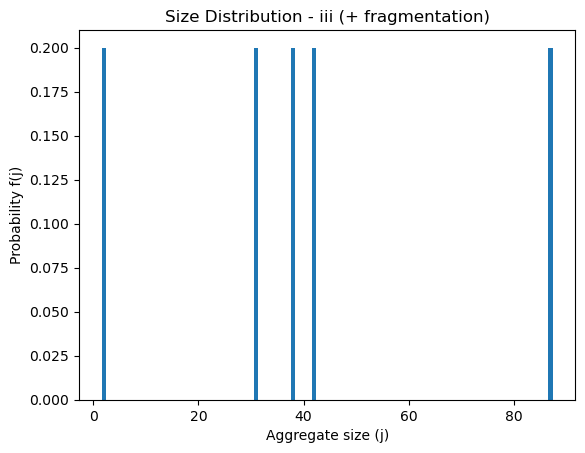

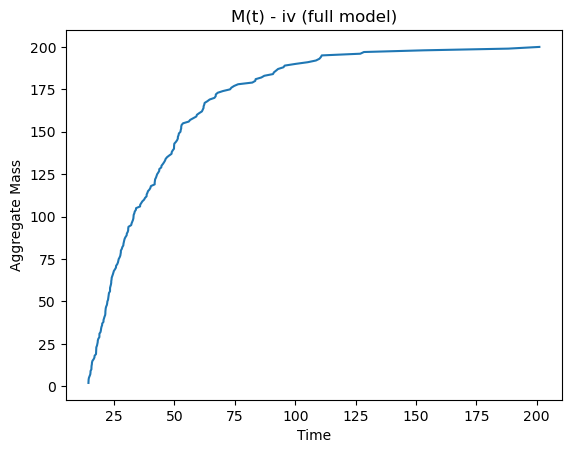

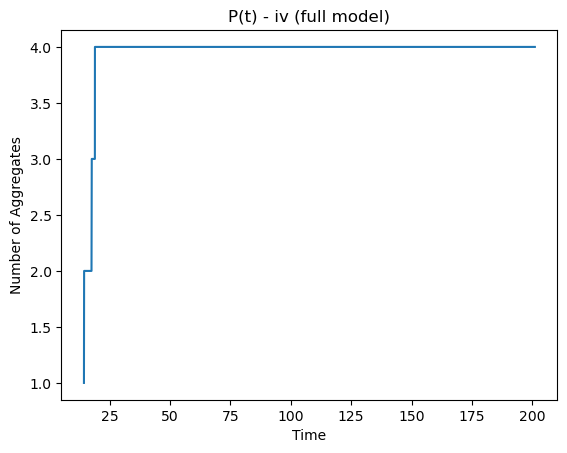

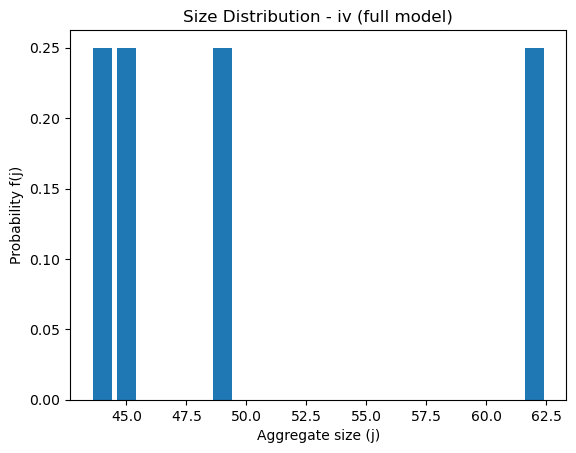

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
import random
from collections import Counter

# ---------------------------
# Fragmentation function
# ---------------------------
def fragment(j):
    if j <= 2:
        return [1, j-1] if j > 1 else []
    cut = random.randint(1, j-1)
    return [cut, j-cut]


# ---------------------------
# Gillespie simulation
# ---------------------------
def simulate(M0, k_n, k_plus, k_minus=0, k_frag=0, n=2, t_max=100):

    t = 0
    M = M0
    polymers = []

    times = []
    M_vals = []
    P_vals = []

    while t < t_max:

        P = len(polymers)

        # propensities
        a1 = k_n * comb(M, n) if M >= n else 0
        a2 = k_plus * M * P
        a3 = k_minus * P
        a4 = k_frag * P

        a0 = a1 + a2 + a3 + a4
        if a0 == 0:
            break

        r1, r2 = np.random.rand(2)
        t += (1/a0) * np.log(1/r1)

        if r2 * a0 < a1:
            # nucleation
            polymers.append(n)
            M -= n

        elif r2 * a0 < a1 + a2:
            # elongation
            i = np.random.randint(len(polymers))
            polymers[i] += 1
            M -= 1

        elif r2 * a0 < a1 + a2 + a3:
            # dissociation
            if P > 0:
                i = np.random.randint(P)
                if polymers[i] > 1:
                    polymers[i] -= 1
                    M += 1
                else:
                    polymers.pop(i)
                    M += 1

        else:
            # fragmentation
            if P > 0:
                i = np.random.randint(P)
                pieces = fragment(polymers[i])
                polymers.pop(i)
                polymers.extend(pieces)

        times.append(t)
        M_vals.append(sum(polymers))
        P_vals.append(len(polymers))

    return times, M_vals, P_vals, polymers


# ---------------------------
# PARAMETERS
# ---------------------------
params = dict(
    M0=200,
    k_n=1e-5,
    k_plus=1e-2,
    n=2,
    t_max=200
)

cases = {
    "i (no dissociation, no fragmentation)": dict(k_minus=0, k_frag=0),
    "ii (+ dissociation)": dict(k_minus=1e-3, k_frag=0),
    "iii (+ fragmentation)": dict(k_minus=0, k_frag=1e-3),
    "iv (full model)": dict(k_minus=1e-3, k_frag=1e-3),
}


# ---------------------------
# RUN SIMULATIONS
# ---------------------------
for name, extra in cases.items():
    t, M, P, polymers = simulate(**params, **extra)

    # M(t)
    plt.figure()
    plt.plot(t, M)
    plt.xlabel("Time")
    plt.ylabel("Aggregate Mass")
    plt.title(f"M(t) - {name}")

    # P(t)
    plt.figure()
    plt.plot(t, P)
    plt.xlabel("Time")
    plt.ylabel("Number of Aggregates")
    plt.title(f"P(t) - {name}")

    # distribution f(j)
    if len(polymers) > 0:
        counts = Counter(polymers)

        sizes = list(counts.keys())
        freqs = list(counts.values())

        total = sum(freqs)
        probs = [f / total for f in freqs]

        plt.figure()
        plt.bar(sizes, probs)
        plt.xlabel("Aggregate size (j)")
        plt.ylabel("Probability f(j)")
        plt.title(f"Size Distribution - {name}")

plt.show()